In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.5 MB/s eta 0:00:00


In [ ]:
#importing Libraries
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display
import joblib
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data_private_forModel.xlsx to data_private_forModel.xlsx


In [ ]:
# Sau khi tải lên, bạn có thể đọc file Excel như sau:
import pandas as pd
df = pd.read_excel('data_private_forModel.xlsx')
df.head()

,ChamNoi,CungNhac,CoLap,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,PhanUngTenGoi,DiNhonChan,ChiTro,TiepXucMat,TargetBinary
0,0,0,0,0,0.0,0.0,0.0,0,0.5,0.0,1
1,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,1
2,0,0,0,1,0.5,0.0,0.0,0,1.0,0.5,1
3,1,0,0,0,0.5,0.0,0.0,0,1.0,0.0,1
4,0,0,0,0,0.0,0.0,0.0,0,0.0,0.5,1


In [ ]:
for i, col in enumerate(df.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: ChamNoi
Vị trí 1: CungNhac
Vị trí 2: CoLap
Vị trí 3: HanhViLapLai
Vị trí 4: KyNangGiaoTiepSom
Vị trí 5: ChoiLuanPhien
Vị trí 6: PhanUngTenGoi
Vị trí 7: DiNhonChan
Vị trí 8: ChiTro
Vị trí 9: TiepXucMat
Vị trí 10: TargetBinary


In [ ]:
# Liệt kê tên các cột
print(df.columns.tolist())
rows, cols = df.shape
print(f"Số hàng: {rows}, Số cột: {cols}")

['ChamNoi', 'CungNhac', 'CoLap', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'TiepXucMat', 'TargetBinary']
Số hàng: 864, Số cột: 11


In [ ]:
X = df.iloc[:, 0:10]      # lấy từ cột 0 đến 13 (14 đặc trưng)
y = df.iloc[:, 10]        # lấy cột TargetBinary (vị trí 14)

# TRAINING VÀ ĐÁNH GIÁ MODEL

==== Đánh giá mô hình CatBoost (chạy đơn) ====
Accuracy :     0.983 – Độ chính xác tổng thể
Recall:       0.980 – Độ nhạy / độ bao phủ của lớp dương
Specificity:  0.987 – Độ đặc hiệu
Precision:    0.990 – Độ chính xác của dự đoán dương
F1-score:     0.985 – Hòa hợp Precision và Recall
ROC AUC:      0.997 – Diện tích dưới đường cong ROC
G-Mean:       0.983 – Trung bình hình học giữa độ nhạy và độ đặc hiệu

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: TiepXucMat, Score: 46.01522
Feature: ChamNoi, Score: 14.76054
Feature: KyNangGiaoTiepSom, Score: 10.28550
Feature: PhanUngTenGoi, Score: 8.93815
Feature: CungNhac, Score: 7.03914
Feature: HanhViLapLai, Score: 4.47001
Feature: ChiTro, Score: 3.32285
Feature: DiNhonChan, Score: 2.41812
Feature: ChoiLuanPhien, Score: 2.01546
Feature: CoLap, Score: 0.73500


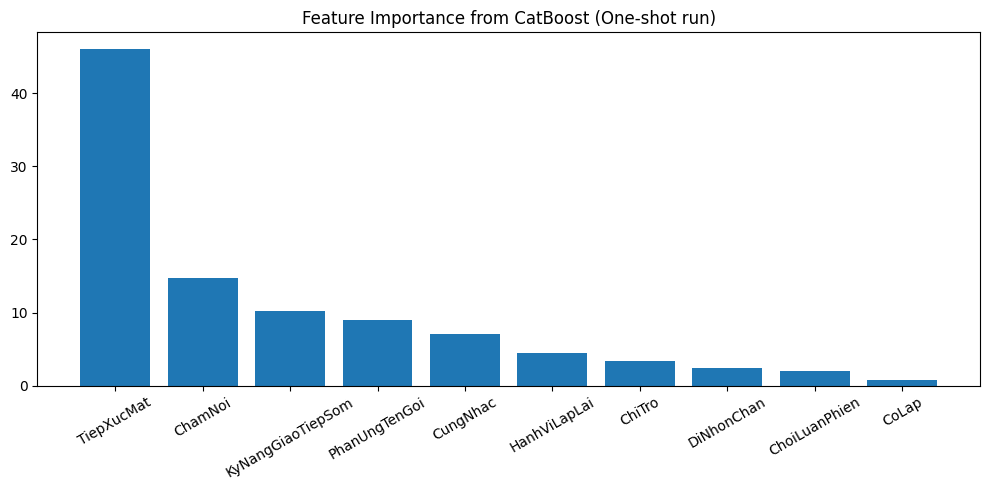

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tách dữ liệu
X = df.drop(columns='TargetBinary')
y = df['TargetBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Khởi tạo CatBoost
model = CatBoostClassifier(
    iterations=300,              # số cây (vòng lặp boosting)
    depth=6,                     # độ sâu của cây
    learning_rate=0.01,          # tốc độ học
    l2_leaf_reg=5,               # regularization để tránh overfitting
    bootstrap_type='Bernoulli', # kiểu sampling
    subsample=0.7,               # tỉ lệ mẫu cho mỗi cây (chỉ dùng khi bootstrap ≠ None)
    loss_function='MultiClass', # dùng nếu bài toán nhiều lớp
    eval_metric='Accuracy',     # metric dùng để theo dõi
    random_state=42,
    verbose=False
)

# 3. Huấn luyện mô hình
model.fit(X_train, y_train)

# 4. Dự đoán
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 5. Tính các độ đo
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix và các độ đo dẫn xuất
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else 0  # giống recall
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(sensitivity * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình CatBoost (chạy đơn) ====")
print(f"Accuracy :     {accuracy:.3f} – Độ chính xác tổng thể")
print(f"Recall:       {recall:.3f} – Độ nhạy / độ bao phủ của lớp dương")
print(f"Specificity:  {specificity:.3f} – Độ đặc hiệu")
print(f"Precision:    {precision:.3f} – Độ chính xác của dự đoán dương")
print(f"F1-score:     {f1:.3f} – Hòa hợp Precision và Recall")
print(f"ROC AUC:      {roc_auc:.3f} – Diện tích dưới đường cong ROC")
print(f"G-Mean:       {gmean:.3f} – Trung bình hình học giữa độ nhạy và độ đặc hiệu")

# 7. Độ quan trọng đặc trưng
importances = model.get_feature_importance()
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 8. Biểu đồ
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from CatBoost (One-shot run)')
plt.tight_layout()
plt.show()


# Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
import numpy as np
import pandas as pd

# 2. Thiết lập Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Danh sách lưu độ đo cho từng Fold
results = []

# 4. Lặp qua từng fold
fold = 1
for train_index, test_index in kf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_test_fold)
    y_proba = model.predict_proba(X_test_fold)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test_fold, y_pred).ravel()

    accuracy = accuracy_score(y_test_fold, y_pred)
    recall = recall_score(y_test_fold, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)
    roc_auc = roc_auc_score(y_test_fold, y_proba)
    gmean = np.sqrt(recall * specificity)

    results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Specificity": specificity,
        "Precision": precision,
        "F1-score": f1,
        "ROC AUC": roc_auc,
        "G-Mean": gmean
    })
    fold += 1

# 5. Tạo DataFrame kết quả
results_df = pd.DataFrame(results)

# 6. Thêm dòng Trung bình
mean_row = {
    "Fold": "Trung bình",
    "Accuracy": results_df["Accuracy"].mean(),
    "Recall": results_df["Recall"].mean(),
    "Specificity": results_df["Specificity"].mean(),
    "Precision": results_df["Precision"].mean(),
    "F1-score": results_df["F1-score"].mean(),
    "ROC AUC": results_df["ROC AUC"].mean(),
    "G-Mean": results_df["G-Mean"].mean()
}
results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

# Làm tròn
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(3)

# 7. In kết quả
print("==== Kết quả Cross-Validation cho CatBoost ====")
print(results_df.to_string(index=False))


==== Kết quả Cross-Validation cho Decision Tree ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1     0.983   0.980        0.987      0.990     0.985    0.994   0.983
         2     0.988   0.980        1.000      1.000     0.990    0.999   0.990
         3     0.971   0.959        0.987      0.989     0.974    0.993   0.973
         4     0.977   0.990        0.960      0.970     0.980    0.999   0.975
         5     0.959   0.928        1.000      1.000     0.963    0.997   0.963
Trung bình     0.976   0.967        0.987      0.990     0.978    0.996   0.977
